<a href="https://colab.research.google.com/github/Kdshah1512/Academics-projects/blob/main/Business_Project_in_Big_Data_%26_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title: Household Power Consumption**

**Import libraries and load dataset**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, recall_score


df = pd.read_csv("/content/Household Power Consumption.csv")



**Inspect Dataset**

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)


**Data Cleaning and Preprocessing**

In [ ]:
print(df.isnull().sum())
df = df.ffill()
print(df.describe())
print(df.head())

Global_active_power      1
Global_reactive_power    1
Voltage                  1
Global_intensity         1
Sub_metering_1           1
Sub_metering_2           1
Sub_metering_3           1
dtype: int64
       Global_active_power  Global_reactive_power     Voltage  \
count           729.000000             729.000000  729.000000   
mean              1.109760               0.118303  239.936105   
std               0.475107               0.031410    2.033989   
min               0.173818               0.057811  231.088229   
25%               0.792969               0.094933  239.498854   
50%               1.094671               0.115249  240.328243   
75%               1.369399               0.134111  241.065243   
max               3.314851               0.272411  243.767361   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count        729.000000      729.000000      729.000000      729.000000  
mean           4.725008        1.173783        1.472617        5

**Exploratory data analysis**

Columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
       Global_active_power  Global_reactive_power     Voltage  \
count           729.000000             729.000000  729.000000   
mean              1.109760               0.118303  239.936105   
std               0.475107               0.031410    2.033989   
min               0.173818               0.057811  231.088229   
25%               0.792969               0.094933  239.498854   
50%               1.094671               0.115249  240.328243   
75%               1.369399               0.134111  241.065243   
max               3.314851               0.272411  243.767361   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count        729.000000      729.000000      729.000000      729.000000  
mean           4.725008        1.173783        1.472617        5.921121  
std            1.977469        1.130635        1.

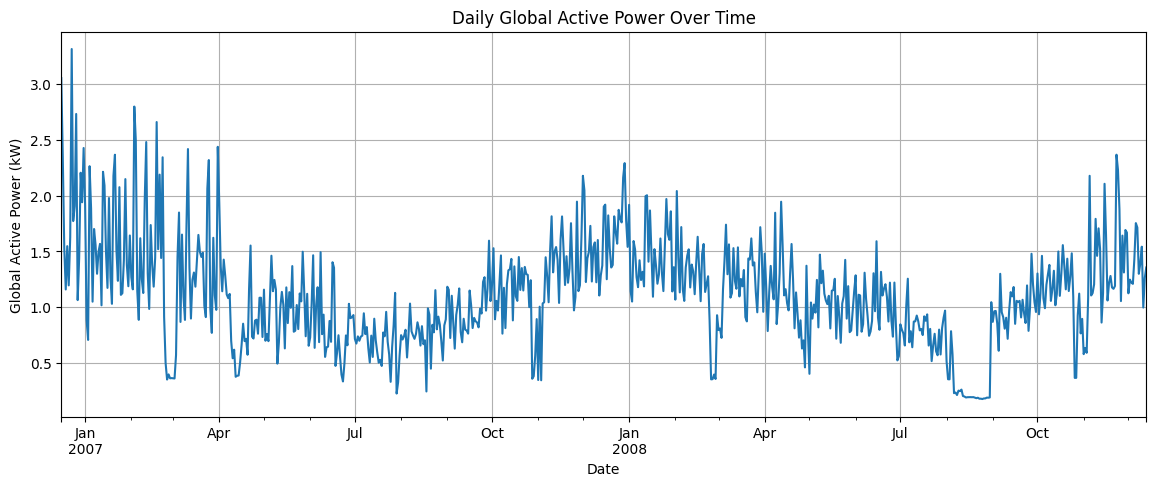

In [ ]:

print("Columns:", df.columns.tolist())
print(df.describe())
print(df.dtypes)

plt.figure(figsize=(14, 5))
df['Global_active_power'].plot(title='Daily Global Active Power Over Time')
plt.ylabel('Global Active Power (kW)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

This plot shows daily global active power consumption over time,it helps identify trends in energy usage.

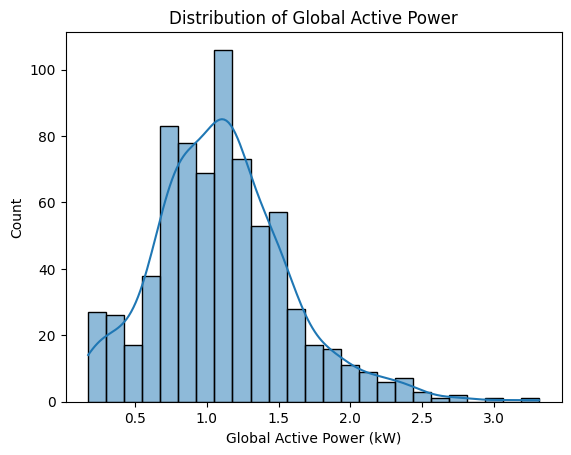

In [ ]:
sns.histplot(df['Global_active_power'], kde=True)
plt.title("Distribution of Global Active Power")
plt.xlabel("Global Active Power (kW)")
plt.show()

in this histogram shows the distribution of global active power values. the KDE curve highlits the dentisy helping us undestand typical range and frequency of enery consumption.

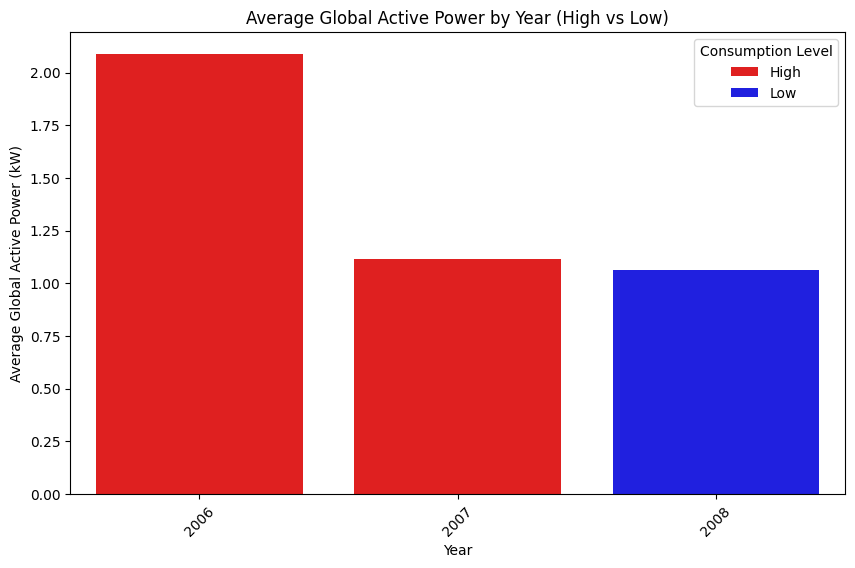

In [ ]:

if 'year' not in df.columns:
    df['year'] = df.index.year

yearly_consumption = df.groupby('year')['Global_active_power'].mean().reset_index()

overall_avg = df['Global_active_power'].mean()


yearly_consumption['level'] = yearly_consumption['Global_active_power'].apply(
    lambda x: 'High' if x > overall_avg else 'Low'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='year',
    y='Global_active_power',
    data=yearly_consumption,
    hue='level',
    palette={'High': 'red', 'Low': 'blue'},
    dodge=False
)
plt.title('Average Global Active Power by Year (High vs Low)')
plt.xlabel('Year')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(rotation=45)
plt.legend(title='Consumption Level')
plt.show()



This barplots showing the average energy consumption per year.the red bar colored indicates high and blue bar colored indicates low consumption of energy.

**feature engineering**


In [ ]:

if not isinstance(df.index, pd.DatetimeIndex):
    if 'Datetime' in df.columns:
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df.set_index('Datetime', inplace=True)
    else:
        print("Error: 'Datetime' column not found to set as index.")

df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)


target_column = 'Global_active_power'
if target_column in df.columns:
    df['lag_1'] = df[target_column].shift(1)
    df['lag_7'] = df[target_column].shift(7)
    df['rolling_mean_7'] = df[target_column].rolling(window=7).mean()
    df['rolling_std_7'] = df[target_column].rolling(window=7).std()
else:
    print(f"Error: Target column '{target_column}' not found.")


df = df.dropna()

features = df.columns.difference([target_column])

print(f"Features used for modeling:\n{features.tolist()}")
print("\nDataFrame after feature engineering:")
print(df.head())

Features used for modeling:
['Global_intensity', 'Global_reactive_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Voltage', 'day', 'day_of_week', 'is_weekend', 'lag_1', 'lag_7', 'month', 'rolling_mean_7', 'rolling_std_7', 'week_of_year', 'year']

DataFrame after feature engineering:
            Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                             
2006-12-23             3.314851               0.153799  240.136076   
2006-12-24             1.770842               0.104097  241.687437   
2006-12-25             1.904944               0.166861  243.399931   
2006-12-26             2.732021               0.114654  241.625438   
2006-12-27             1.061639               0.124237  243.767361   

            Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
Datetime                                                                       
2006-12-23         14.028056        1.853472      

The code changes the date column into a proper date format and takes out useful time parts like year,month and day.it also creates new features that shows past values and average of the main data.

**Model training and decision tree evolution**

In [ ]:



target = 'Global_active_power'

features = df.columns.difference([target])


split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]


reg_tree = DecisionTreeRegressor(random_state=42)
reg_tree.fit(X_train, y_train)


y_pred_reg = reg_tree.predict(X_test)


mae = mean_absolute_error(y_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2 = r2_score(y_test, y_pred_reg)

print("Decision Tree Regressor Performance:")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")

Decision Tree Regressor Performance:
MAE: 0.021
RMSE: 0.028
R2: 0.997


The data is split into test and train as 80% trainand 20% test.A decision tree is trained on the trained data to predict(global active power).

**Visualizing model**

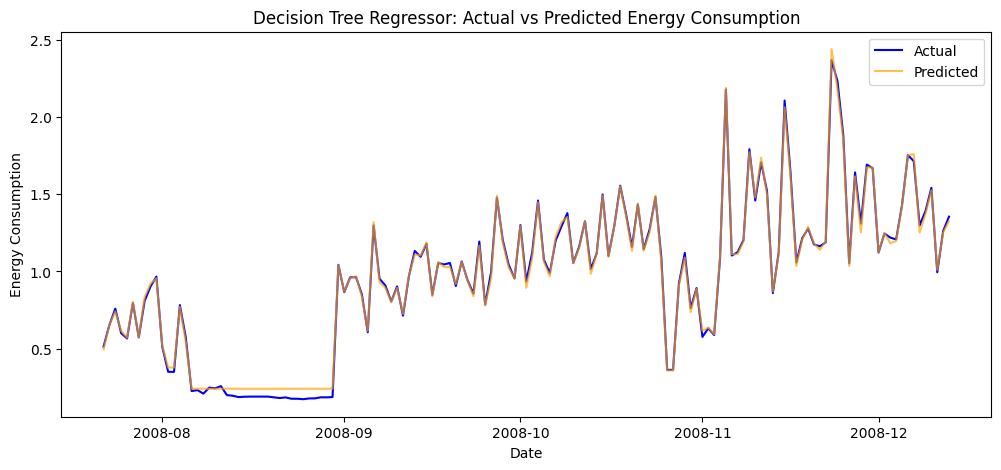

In [ ]:


plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label='Actual', color='blue')
plt.plot(y_test.index, y_pred_reg, label='Predicted', color='orange', alpha=0.7)
plt.title('Decision Tree Regressor: Actual vs Predicted Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.legend()
plt.show()


This code visualize the comparison between the actual and predicted enery consumption.we can see decision tree model prediction match the actual energy use over time.

**compare model performance**

In [ ]:



reg_linear = LinearRegression()
reg_linear.fit(X_train, y_train)

y_pred_linear = reg_linear.predict(X_test)

# Decision Tree metrics
mae_tree = mean_absolute_error(y_test, y_pred_reg)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2_tree = r2_score(y_test, y_pred_reg)

# Linear Regression metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Decision Tree': [f"{mae_tree:.3f}", f"{rmse_tree:.3f}", f"{r2_tree:.3f}"],
    'Linear Regression': [f"{mae_linear:.3f}", f"{rmse_linear:.3f}", f"{r2_linear:.3f}"]
})

print("Model Performance Comparison:")
print(summary)




Model Performance Comparison:
  Metric Decision Tree Linear Regression
0    MAE         0.021             0.008
1   RMSE         0.028             0.011
2     R²         0.997             0.999


This step calculates significant assessment measures — Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) for Linear Regression and Decision Tree Regressor models. The outputs are given through a table for convenient comparison between each model's ability to predict electricity usage.

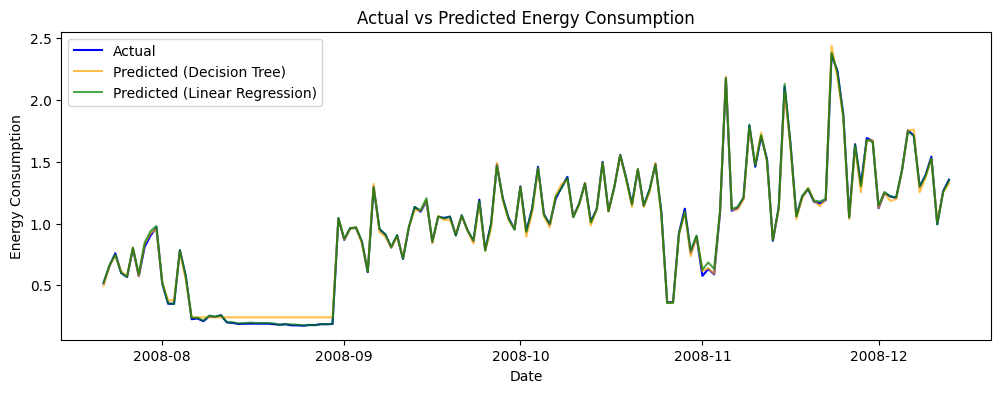

In [ ]:

plt.figure(figsize=(12, 4))
plt.plot(y_test.index, y_test, label='Actual', color='blue')
plt.plot(y_test.index, y_pred_reg, label='Predicted (Decision Tree)', color='orange', alpha=0.7)

plt.plot(y_test.index, y_pred_linear, label='Predicted (Linear Regression)', color='green', alpha=0.7)

plt.title('Actual vs Predicted Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.legend()
plt.show()


In this plot, the actual energy consumption is displayed along with the forecasts made using Decision Tree Regressor and Linear Regression models. Checking predictions in this way helps evaluate both models based on their accuracy capturing the trends and patterns within the test data.

